# RTW Readiness Prediction in Cancer Survivors

This notebook presents an exploratory and explanatory walkthrough of the **Return-to-Work (RTW) Readiness Prediction** project.

It complements the project scripts by showing:
- the problem framing
- the synthetic dataset structure
- key descriptive insights
- model performance comparison
- interpretation of the main predictors

**Project context:** Cancer survivors may face persistent fatigue, cognitive limitations, anxiety, pain, and workplace-related barriers when considering a return to work. This notebook explores whether those factors can help predict RTW readiness using machine learning.


## 1. Setup

This notebook expects the following project structure:

```text
cancer-rtw-readiness/
├── data/
│   ├── generate_dataset.py
│   └── synthetic_rtw_dataset.csv
├── model/
│   └── train_evaluate.py
├── notebooks/
│   └── rtw_analysis.ipynb
└── visuals/
```

If the CSV does not yet exist, run `python train_evaluate.py` from the `model/` folder first, or generate the dataset from `data/generate_dataset.py`.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    average_precision_score,
)

sns.set_theme(style='whitegrid')

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_DIR = PROJECT_ROOT / 'data'
CSV_PATH = DATA_DIR / 'synthetic_rtw_dataset.csv'

if not CSV_PATH.exists():
    import sys
    sys.path.insert(0, str(PROJECT_ROOT))
    from data.generate_dataset import generate_dataset
    df = generate_dataset(400)
    CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(CSV_PATH, index=False)
else:
    df = pd.read_csv(CSV_PATH)

print(f'Project root: {PROJECT_ROOT}')
print(f'Dataset path: {CSV_PATH}')
print(f'Dataset shape: {df.shape}')


Project root: /home/ninahoang/cancer-rtw-readiness
Dataset path: /home/ninahoang/cancer-rtw-readiness/data/synthetic_rtw_dataset.csv
Dataset shape: (400, 19)


## 2. Preview the dataset

The dataset is synthetic, but its feature design and label logic are grounded in published RTW survivorship literature. It includes clinical, functional, psychological, and work-related variables.


In [2]:
df.head()

,cancer_type,treatment_type,months_since_treatment,disease_stage,comorbidities,fatigue_score,pain_score,cognitive_limitation_score,physical_functioning_score,anxiety_score,depression_indicator,rtw_confidence_score,work_behavior_type,socioeconomic_status,job_type,employer_flexibility,employer_support,age,rtw_ready
0,breast,surgery_only,17,III,0,3.6,2.7,6.2,6.0,1.0,0,10.0,healthy_ambitious,low,mixed,high,1,55,1
1,other,surgery_radiation,2,I,0,3.7,3.2,1.9,6.2,4.1,1,6.8,unambitious,low,physical,high,1,51,1
2,prostate,surgery_chemo,12,I,0,5.0,3.3,7.3,4.9,2.6,0,4.2,healthy_ambitious,middle,sedentary,low,1,59,1
3,colorectal,surgery_chemo_radiation,13,I,0,6.3,7.2,5.3,3.2,1.2,0,4.2,excessively_ambitious,high,mixed,low,1,53,1
4,breast,surgery_chemo,7,II,0,7.5,1.0,4.0,2.7,2.2,1,5.3,excessively_ambitious,middle,mixed,high,1,42,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cancer_type                 400 non-null    object 
 1   treatment_type              400 non-null    object 
 2   months_since_treatment      400 non-null    int64  
 3   disease_stage               400 non-null    object 
 4   comorbidities               400 non-null    int64  
 5   fatigue_score               400 non-null    float64
 6   pain_score                  400 non-null    float64
 7   cognitive_limitation_score  400 non-null    float64
 8   physical_functioning_score  400 non-null    float64
 9   anxiety_score               400 non-null    float64
 10  depression_indicator        400 non-null    int64  
 11  rtw_confidence_score        400 non-null    float64
 12  work_behavior_type          400 non-null    object 
 13  socioeconomic_status        400 non

## 3. Target distribution

A healthy first step is to inspect the class balance. This affects model evaluation and helps us understand whether the dataset is heavily skewed.


In [4]:
target_counts = df['rtw_ready'].value_counts().sort_index()
target_labels = ['Not Ready', 'Ready']

pd.DataFrame({
    'class': target_labels,
    'count': [target_counts.get(0, 0), target_counts.get(1, 0)],
    'proportion': [target_counts.get(0, 0)/len(df), target_counts.get(1, 0)/len(df)]
})


,class,count,proportion
0,Not Ready,152,0.38
1,Ready,248,0.62


/tmp/ipykernel_10835/693040614.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(target_labels)


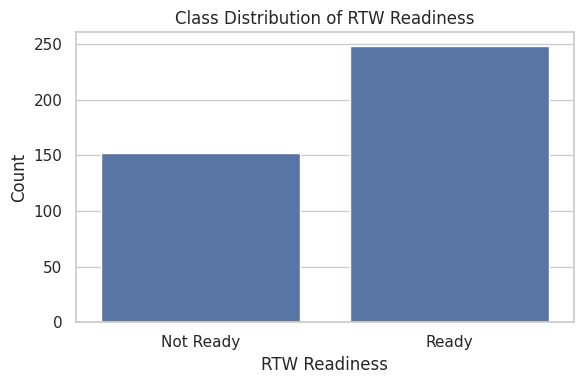

In [5]:
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x='rtw_ready')
ax.set_xticklabels(target_labels)
ax.set_xlabel('RTW Readiness')
ax.set_ylabel('Count')
ax.set_title('Class Distribution of RTW Readiness')
plt.tight_layout()
plt.show()


## 4. Descriptive clinical insights

Before modeling, it helps to examine several variables that are clinically meaningful and likely to influence RTW readiness.


In [6]:
summary = (
    df.groupby('rtw_ready')[['fatigue_score', 'physical_functioning_score', 'rtw_confidence_score', 'anxiety_score']]
      .mean()
      .rename(index={0: 'Not Ready', 1: 'Ready'})
)
summary.round(2)


,fatigue_score,physical_functioning_score,rtw_confidence_score,anxiety_score
rtw_ready,,,,
Not Ready,6.94,3.09,4.31,5.80
Ready,4.69,5.28,5.96,4.65


/tmp/ipykernel_10835/3572896515.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(target_labels)
/tmp/ipykernel_10835/3572896515.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(target_labels)


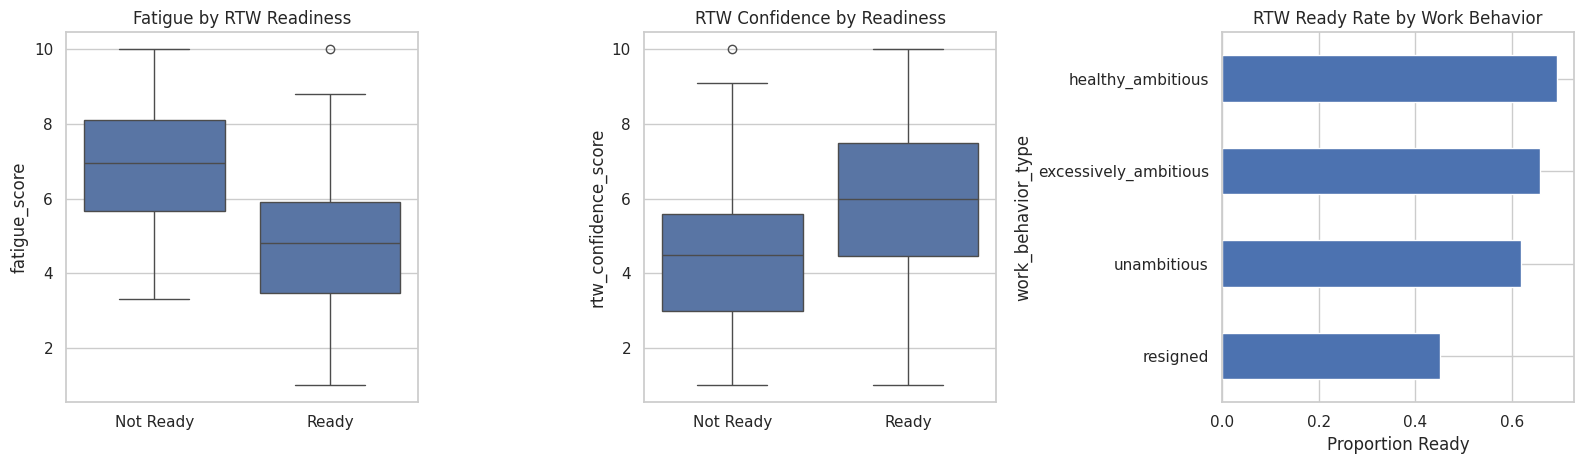

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

sns.boxplot(data=df, x='rtw_ready', y='fatigue_score', ax=axes[0])
axes[0].set_xticklabels(target_labels)
axes[0].set_title('Fatigue by RTW Readiness')
axes[0].set_xlabel('')

sns.boxplot(data=df, x='rtw_ready', y='rtw_confidence_score', ax=axes[1])
axes[1].set_xticklabels(target_labels)
axes[1].set_title('RTW Confidence by Readiness')
axes[1].set_xlabel('')

wb = df.groupby('work_behavior_type')['rtw_ready'].mean().sort_values()
wb.plot(kind='barh', ax=axes[2])
axes[2].set_title('RTW Ready Rate by Work Behavior')
axes[2].set_xlabel('Proportion Ready')

plt.tight_layout()
plt.show()


### Interpretation

- Lower fatigue tends to align with greater readiness to return to work.
- Higher confidence to return appears positively associated with readiness.
- Work behavior patterns may also matter, especially where resignation or reduced motivation is present.


## 5. Feature setup for modeling

We will reproduce the modeling pipeline using:
- **Logistic Regression** as an interpretable baseline
- **Random Forest** as a non-linear ensemble model


In [9]:
TARGET = 'rtw_ready'

NUMERIC_FEATURES = [
    'fatigue_score', 'pain_score', 'cognitive_limitation_score',
    'physical_functioning_score', 'anxiety_score', 'rtw_confidence_score',
    'months_since_treatment', 'comorbidities', 'age',
    'depression_indicator', 'employer_support',
]

CATEGORICAL_FEATURES = [
    'cancer_type', 'treatment_type', 'disease_stage',
    'work_behavior_type', 'socioeconomic_status',
    'job_type', 'employer_flexibility',
]

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUMERIC_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_FEATURES),
])

lr_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, C=1.0)),
])

rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
    )),
])

models = {
    'Logistic Regression': lr_pipeline,
    'Random Forest': rf_pipeline,
}


## 6. Cross-validation performance

Cross-validation gives a more stable estimate of model performance than relying on a single train/test split.


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []

for name, model in models.items():
    auc_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_rows.append({
        'model': name,
        'mean_cv_auc': auc_scores.mean(),
        'std_cv_auc': auc_scores.std(),
        'scores': auc_scores,
    })

cv_df = pd.DataFrame(cv_rows)
cv_df[['model', 'mean_cv_auc', 'std_cv_auc']].round(3)


In [ ]:
plt.figure(figsize=(7,4.5))
plot_df = pd.DataFrame({
    'model': np.repeat(cv_df['model'].values, 5),
    'auc': np.concatenate(cv_df['scores'].values)
})
sns.boxplot(data=plot_df, x='model', y='auc')
plt.ylim(0.5, 1.0)
plt.title('5-Fold Cross-Validation ROC-AUC')
plt.xlabel('')
plt.tight_layout()
plt.show()


## 7. Test-set evaluation

Now we fit each model on the training set and evaluate on the held-out test set.


In [ ]:
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    trained_models[name] = {'model': model, 'y_pred': y_pred, 'y_prob': y_prob}
    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'avg_precision': average_precision_score(y_test, y_prob),
    })

results_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False)
results_df.round(3)


In [ ]:
for name in trained_models:
    print(f'\n{name}')
    print(classification_report(y_test, trained_models[name]['y_pred'], target_names=['Not Ready', 'Ready']))


In [ ]:
plt.figure(figsize=(7,5))
for name, res in trained_models.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc = roc_auc_score(y_test, res['y_prob'])
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves on Test Set')
plt.legend()
plt.tight_layout()
plt.show()


### Interpretation

If Logistic Regression performs especially well here, that is not surprising. The synthetic label generation logic is largely based on a weighted scoring formula, which is closer to a linear decision process than many real-world datasets.


## 8. Random Forest feature importance

We inspect the Random Forest because it offers a straightforward feature importance measure. This helps identify the strongest drivers of RTW readiness in the synthetic data.


In [ ]:
rf_model = trained_models['Random Forest']['model']
prep = rf_model.named_steps['prep']
rf_clf = rf_model.named_steps['clf']

cat_feature_names = list(prep.named_transformers_['cat'].get_feature_names_out(CATEGORICAL_FEATURES))
all_feature_names = NUMERIC_FEATURES + cat_feature_names

importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': rf_clf.feature_importances_,
}).sort_values('importance', ascending=False)

def map_to_original(feat_name):
    for orig in CATEGORICAL_FEATURES:
        if feat_name.startswith(orig + '_'):
            return orig
    return feat_name

importance_df['original_feature'] = importance_df['feature'].apply(map_to_original)
grouped_importance = (
    importance_df.groupby('original_feature')['importance']
    .sum()
    .reset_index()
    .sort_values('importance', ascending=False)
    .rename(columns={'original_feature': 'feature'})
)

grouped_importance.head(12).round(4)


In [ ]:
top_imp = grouped_importance.head(12).sort_values('importance')
plt.figure(figsize=(8,5.5))
plt.barh(top_imp['feature'], top_imp['importance'])
plt.xlabel('Feature Importance')
plt.title('Top Random Forest Feature Importances')
plt.tight_layout()
plt.show()


### Interpretation

In this project, fatigue, physical functioning, and RTW confidence are expected to emerge as leading predictors. That aligns with the literature-based logic used to construct the synthetic dataset.


## 9. Focused clinical subgroup checks

These calculations mirror the kinds of interpretable statements that are useful in a README, presentation, or healthcare discussion.


In [ ]:
high_fatigue = df[df['fatigue_score'] > 7]['rtw_ready'].mean()
low_fatigue = df[df['fatigue_score'] <= 4]['rtw_ready'].mean()
high_fatigue_high_anxiety = df[(df['fatigue_score'] > 7) & (df['anxiety_score'] > 6)]['rtw_ready'].mean()

subgroup_summary = pd.DataFrame({
    'group': [
        'Fatigue > 7',
        'Fatigue ≤ 4',
        'Fatigue > 7 and Anxiety > 6'
    ],
    'rtw_ready_rate': [high_fatigue, low_fatigue, high_fatigue_high_anxiety]
})
subgroup_summary.round(3)


In [ ]:
work_behavior_summary = (
    df.groupby('work_behavior_type')['rtw_ready']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
      .rename(columns={'rtw_ready': 'rtw_ready_rate'})
)
work_behavior_summary.round(3)


## 10. Conclusion

This notebook complements the project scripts by showing the analytical story behind the RTW readiness project.

### Main takeaways
- RTW readiness can be framed as a clinically meaningful prediction problem.
- Symptom burden and psychosocial factors appear central to prediction.
- Fatigue, physical functioning, and confidence to return to work stand out as especially influential variables.
- Because the dataset is synthetic and literature-informed, the project is best understood as a **proof of concept** rather than a clinically validated tool.

### Possible next steps
- add SHAP-based explainability
- build a Streamlit demo
- extend the work to a GenAI-assisted RTW planning tool
- test the approach on real-world survivorship or registry data if available
